In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
# Basic parameters

IMG_HEIGHT = 28
IMG_WIDTH = 28
CHANNELS = 1

BATCH_SIZE = 128
NOISE_DIM = 100
EPOCHS = 25

print("Image size:", IMG_HEIGHT, "x", IMG_WIDTH)
print("Batch size:", BATCH_SIZE)
print("Noise dimension:", NOISE_DIM)
print("Epochs:", EPOCHS)

Image size: 28 x 28
Batch size: 128
Noise dimension: 100
Epochs: 25


In [ ]:
# Fixed / hardcoded noise vector
np.random.seed(42)

fixed_noise = tf.random.normal([16, NOISE_DIM], seed=42)

print("Fixed noise shape:", fixed_noise.shape)

Fixed noise shape: (16, 100)


In [ ]:
# Load Fashion-MNIST dataset

(x_train, _), (_, _) = tf.keras.datasets.fashion_mnist.load_data()

print("Dataset shape:", x_train.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Dataset shape: (60000, 28, 28)


In [ ]:
# Normalize images from [0, 255] to [-1, 1]

x_train = x_train.astype("float32")
x_train = (x_train - 127.5) / 127.5

# Add channel dimension
x_train = np.expand_dims(x_train, axis=-1)

print("New dataset shape:", x_train.shape)
print("Minimum value:", x_train.min())
print("Maximum value:", x_train.max())

New dataset shape: (60000, 28, 28, 1)
Minimum value: -1.0
Maximum value: 1.0


In [ ]:
# Create TensorFlow dataset

train_dataset = tf.data.Dataset.from_tensor_slices(x_train)

train_dataset = train_dataset.shuffle(
    buffer_size=60000
).batch(BATCH_SIZE)

print("Dataset ready!")

Dataset ready!


In [ ]:
# Generator

def build_generator():

    model = tf.keras.Sequential(name="Generator")

    # Random noise: 100 values
    model.add(
        tf.keras.layers.Dense(
            7 * 7 * 256,
            use_bias=False,
            input_shape=(NOISE_DIM,)
        )
    )

    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.LeakyReLU())

    # Convert to 7 x 7 x 256
    model.add(
        tf.keras.layers.Reshape((7, 7, 256))
    )

    # 7x7 -> 14x14
    model.add(
        tf.keras.layers.Conv2DTranspose(
            128,
            kernel_size=5,
            strides=2,
            padding="same",
            use_bias=False
        )
    )

    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.LeakyReLU())

    # 14x14 -> 28x28
    model.add(
        tf.keras.layers.Conv2DTranspose(
            64,
            kernel_size=5,
            strides=2,
            padding="same",
            use_bias=False
        )
    )

    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.LeakyReLU())

    # Final image layer
    model.add(
        tf.keras.layers.Conv2DTranspose(
            1,
            kernel_size=5,
            strides=1,
            padding="same",
            activation="tanh"
        )
    )

    return model


generator = build_generator()

generator.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 128)    │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,601 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,945 (8.89 MB)

 Trainable params: 2,305,473 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

In [ ]:
# Test generator before training

generated_images = generator(fixed_noise, training=False)

print("Generated image shape:", generated_images.shape)

Generated image shape: (16, 28, 28, 1)


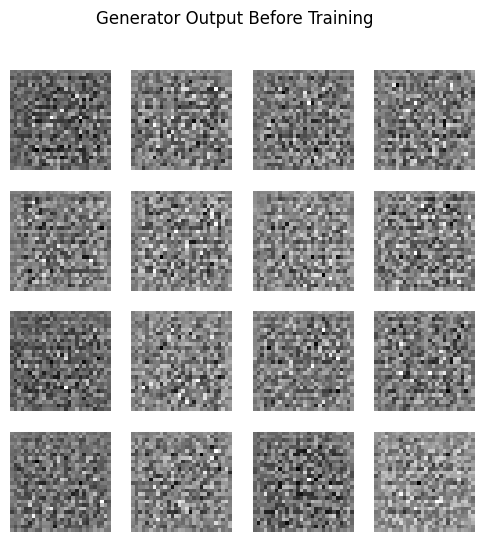

In [ ]:
# Display generated images before training

plt.figure(figsize=(6, 6))

for i in range(16):
    plt.subplot(4, 4, i + 1)

    image = (generated_images[i, :, :, 0] + 1) / 2

    plt.imshow(image, cmap="gray")
    plt.axis("off")

plt.suptitle("Generator Output Before Training")
plt.show()

In [ ]:
# Discriminator

def build_discriminator():

    model = tf.keras.Sequential(name="Discriminator")

    model.add(
        tf.keras.layers.Conv2D(
            64,
            kernel_size=5,
            strides=2,
            padding="same",
            input_shape=(28, 28, 1)
        )
    )

    model.add(tf.keras.layers.LeakyReLU())
    model.add(tf.keras.layers.Dropout(0.3))

    model.add(
        tf.keras.layers.Conv2D(
            128,
            kernel_size=5,
            strides=2,
            padding="same"
        )
    )

    model.add(tf.keras.layers.LeakyReLU())
    model.add(tf.keras.layers.Dropout(0.3))

    model.add(tf.keras.layers.Flatten())

    # Sigmoid -> probability of real
    model.add(
        tf.keras.layers.Dense(
            1,
            activation="sigmoid"
        )
    )

    return model


discriminator = build_discriminator()

discriminator.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Test discriminator

decision = discriminator(generated_images)

print("Discriminator output shape:", decision.shape)
print("First 5 outputs:")
print(decision[:5].numpy())

Discriminator output shape: (16, 1)
First 5 outputs:
[[0.5005636]
 [0.5005252]
 [0.5006889]
 [0.5012735]
 [0.5003445]]


In [ ]:
# Binary Cross-Entropy loss

cross_entropy = tf.keras.losses.BinaryCrossentropy(
    from_logits=False
)

In [ ]:
def discriminator_loss(real_output, fake_output):

    real_loss = cross_entropy(
        tf.ones_like(real_output),
        real_output
    )

    fake_loss = cross_entropy(
        tf.zeros_like(fake_output),
        fake_output
    )

    total_loss = real_loss + fake_loss

    return total_loss


def generator_loss(fake_output):

    return cross_entropy(
        tf.ones_like(fake_output),
        fake_output
    )

In [ ]:
# Optimizers

generator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

discriminator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

In [ ]:
# One training step

@tf.function
def train_step(images):

    noise = tf.random.normal(
        [BATCH_SIZE, NOISE_DIM]
    )

    with tf.GradientTape() as gen_tape, \
         tf.GradientTape() as disc_tape:

        # Generate fake images
        generated_images = generator(
            noise,
            training=True
        )

        # Discriminator predictions
        real_output = discriminator(
            images,
            training=True
        )

        fake_output = discriminator(
            generated_images,
            training=True
        )

        # Calculate losses
        gen_loss = generator_loss(fake_output)

        disc_loss = discriminator_loss(
            real_output,
            fake_output
        )

    # Calculate gradients
    gradients_of_generator = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    gradients_of_discriminator = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    # Update weights
    generator_optimizer.apply_gradients(
        zip(
            gradients_of_generator,
            generator.trainable_variables
        )
    )

    discriminator_optimizer.apply_gradients(
        zip(
            gradients_of_discriminator,
            discriminator.trainable_variables
        )
    )

    return gen_loss, disc_loss

In [ ]:
def generate_and_save_images(epoch):

    predictions = generator(
        fixed_noise,
        training=False
    )

    plt.figure(figsize=(6, 6))

    for i in range(16):

        plt.subplot(4, 4, i + 1)

        image = (predictions[i, :, :, 0] + 1) / 2

        plt.imshow(image, cmap="gray")
        plt.axis("off")

    plt.suptitle(f"Generated Images - Epoch {epoch}")

    plt.tight_layout()

    # Save image
    filename = f"generated_epoch_{epoch}.png"
    plt.savefig(filename)

    plt.show()

    print("Saved:", filename)


Epoch 1/25
Generator Loss: 0.7057 | Discriminator Loss: 1.3629

Epoch 2/25
Generator Loss: 0.7000 | Discriminator Loss: 1.3721

Epoch 3/25
Generator Loss: 0.7496 | Discriminator Loss: 1.3127

Epoch 4/25
Generator Loss: 0.7962 | Discriminator Loss: 1.2879

Epoch 5/25
Generator Loss: 0.7535 | Discriminator Loss: 1.3511


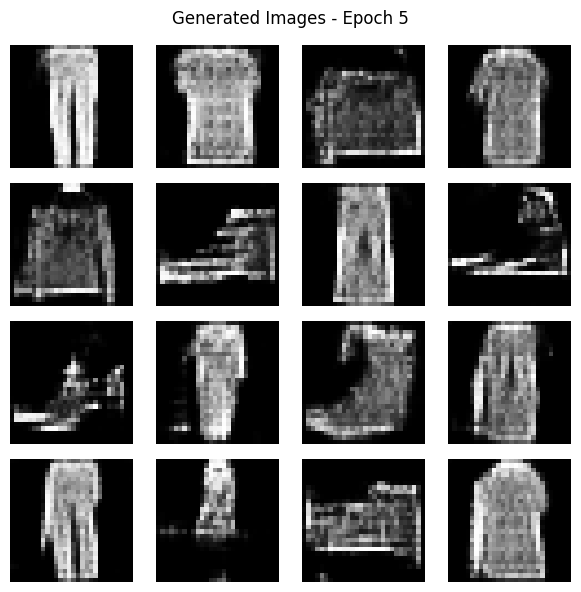

Saved: generated_epoch_5.png

Epoch 6/25
Generator Loss: 0.7413 | Discriminator Loss: 1.3519

Epoch 7/25
Generator Loss: 0.7361 | Discriminator Loss: 1.3542

Epoch 8/25
Generator Loss: 0.7707 | Discriminator Loss: 1.3340

Epoch 9/25
Generator Loss: 0.7308 | Discriminator Loss: 1.3560

Epoch 10/25
Generator Loss: 0.7415 | Discriminator Loss: 1.3545


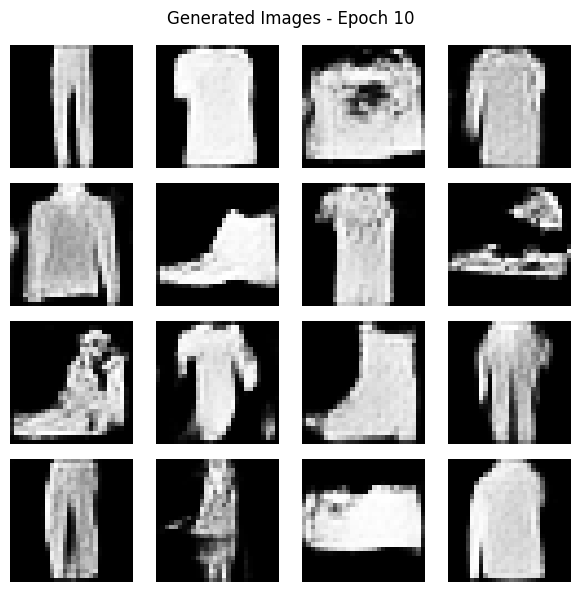

Saved: generated_epoch_10.png

Epoch 11/25
Generator Loss: 0.7291 | Discriminator Loss: 1.3601

Epoch 12/25
Generator Loss: 0.7456 | Discriminator Loss: 1.3513

Epoch 13/25
Generator Loss: 0.7304 | Discriminator Loss: 1.3592

Epoch 14/25
Generator Loss: 0.7540 | Discriminator Loss: 1.3447

Epoch 15/25
Generator Loss: 0.7344 | Discriminator Loss: 1.3562


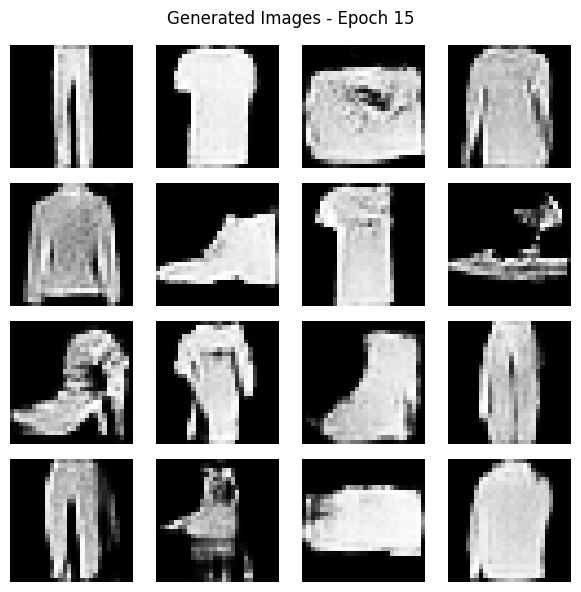

Saved: generated_epoch_15.png

Epoch 16/25
Generator Loss: 0.7497 | Discriminator Loss: 1.3483

Epoch 17/25
Generator Loss: 0.7345 | Discriminator Loss: 1.3582

Epoch 18/25
Generator Loss: 0.7395 | Discriminator Loss: 1.3566

Epoch 19/25
Generator Loss: 0.7425 | Discriminator Loss: 1.3567

Epoch 20/25
Generator Loss: 0.7401 | Discriminator Loss: 1.3572


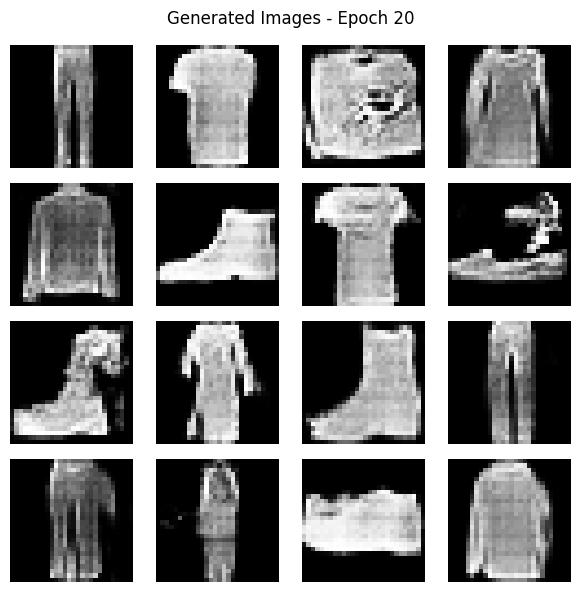

Saved: generated_epoch_20.png

Epoch 21/25
Generator Loss: 0.7363 | Discriminator Loss: 1.3585

Epoch 22/25
Generator Loss: 0.7452 | Discriminator Loss: 1.3572

Epoch 23/25
Generator Loss: 0.7374 | Discriminator Loss: 1.3593

Epoch 24/25
Generator Loss: 0.7380 | Discriminator Loss: 1.3578

Epoch 25/25
Generator Loss: 0.7401 | Discriminator Loss: 1.3572


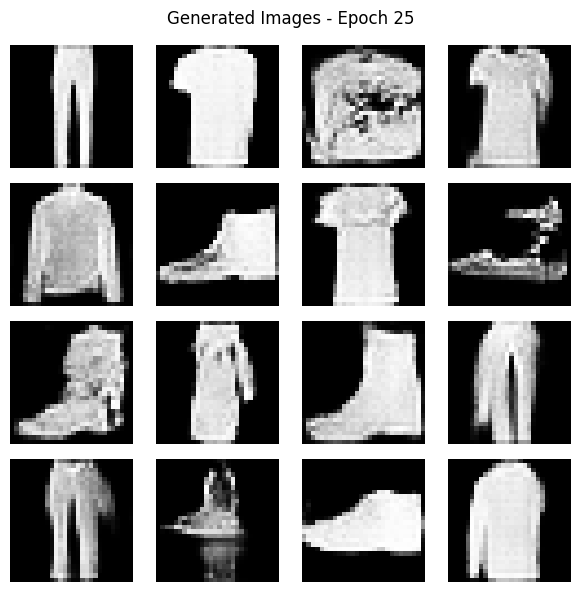

Saved: generated_epoch_25.png


In [ ]:
# Training

generator_losses = []
discriminator_losses = []

for epoch in range(1, EPOCHS + 1):

    print(f"\nEpoch {epoch}/{EPOCHS}")

    epoch_gen_loss = []
    epoch_disc_loss = []

    for image_batch in train_dataset:

        gen_loss, disc_loss = train_step(image_batch)

        epoch_gen_loss.append(gen_loss.numpy())
        epoch_disc_loss.append(disc_loss.numpy())

    # Average losses for this epoch
    avg_gen_loss = np.mean(epoch_gen_loss)
    avg_disc_loss = np.mean(epoch_disc_loss)

    generator_losses.append(avg_gen_loss)
    discriminator_losses.append(avg_disc_loss)

    print(
        f"Generator Loss: {avg_gen_loss:.4f} | "
        f"Discriminator Loss: {avg_disc_loss:.4f}"
    )

    # Save image every 5 epochs
    if epoch % 5 == 0:
        generate_and_save_images(epoch)

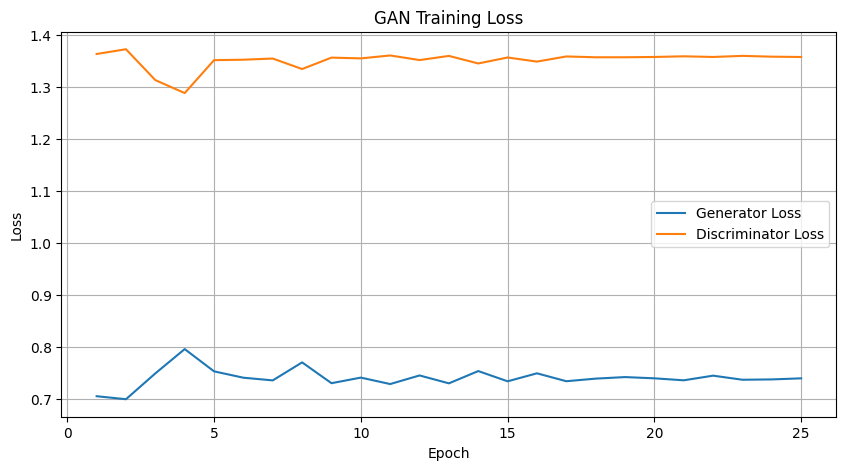

In [ ]:
# Plot Generator and Discriminator losses

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, EPOCHS + 1),
    generator_losses,
    label="Generator Loss"
)

plt.plot(
    range(1, EPOCHS + 1),
    discriminator_losses,
    label="Discriminator Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Loss")
plt.legend()
plt.grid(True)

plt.show()

**Q1. How do images change from Epoch 5 to Epoch 25?**

At Epoch 5, the generated images show recognizable clothing-like structures but are blurry and noisy. By Epoch 10, the shapes become clearer and more defined. From Epoch 15 to Epoch 20, the generated images become more stable and detailed. At Epoch 25, most images are recognizable, although some artifacts and distortions remain. Overall, the image quality improves mainly during the early stages of training and becomes relatively stable later.

**Q2. Can you observe instability in training?**

Yes, some instability can be observed because the Generator and Discriminator losses fluctuate during training rather than decreasing smoothly. However, the losses become relatively stable after the initial epochs, so the training does not show severe instability.

**Q3. At which epoch do cloth-like shapes become recognizable?**

Cloth-like shapes become recognizable around Epoch 5. Although the images are still blurry and noisy at this stage, clothing categories such as shirts, trousers and shoes can already be distinguished.

**Q4. Does the image continue improving throughout the training?**

No. The images improve significantly during the early epochs, especially between Epoch 5 and Epoch 10. After approximately Epoch 15–20, the generated images become relatively stable and further training results in only limited visual improvement. Therefore, the image quality appears to reach a plateau during the later stages of training.

# Part 2: VAE Practical Demo

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Load MNIST dataset

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


In [ ]:
# Normalize pixel values

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Minimum:", x_train.min())
print("Maximum:", x_train.max())

Minimum: 0.0
Maximum: 1.0


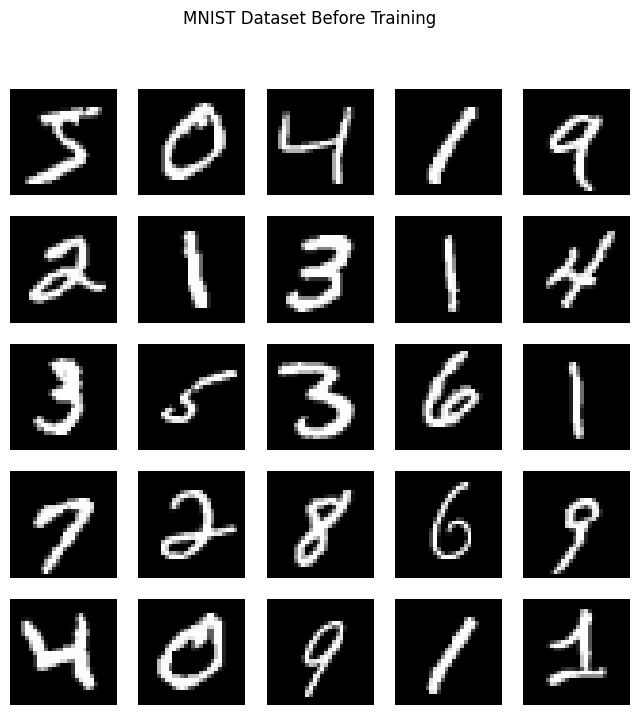

In [ ]:
# Display sample MNIST images

plt.figure(figsize=(8, 8))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.axis("off")

plt.suptitle("MNIST Dataset Before Training")
plt.show()

In [ ]:
# Normal Autoencoder

latent_dim = 2

encoder = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="sigmoid"),
    tf.keras.layers.Dense(64, activation="sigmoid"),
    tf.keras.layers.Dense(latent_dim, activation="linear")
], name="AE_Encoder")


decoder = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(latent_dim,)),
    tf.keras.layers.Dense(64, activation="sigmoid"),
    tf.keras.layers.Dense(128, activation="sigmoid"),
    tf.keras.layers.Dense(784, activation="sigmoid"),
    tf.keras.layers.Reshape((28, 28))
], name="AE_Decoder")


autoencoder = tf.keras.Sequential([
    encoder,
    decoder
], name="Autoencoder")

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder.summary()

Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ AE_Encoder (Sequential)         │ (None, 2)              │       108,866 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ AE_Decoder (Sequential)         │ (None, 28, 28)         │       109,648 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 218,514 (853.57 KB)

 Trainable params: 218,514 (853.57 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the normal Autoencoder

ae_history = autoencoder.fit(
    x_train,
    x_train,
    epochs=15,
    batch_size=128,
    validation_data=(x_test, x_test)
)

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0698 - val_loss: 0.0618
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0601 - val_loss: 0.0586
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0556 - val_loss: 0.0532
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0520 - val_loss: 0.0506
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0496 - val_loss: 0.0487
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0480 - val_loss: 0.0475
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0468 - val_loss: 0.0464
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0457 - val_loss: 0.0454
Epoch 9/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0447 - val_loss: 0.0445
Epoch 10/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0438 - val_loss: 0.0436
Epoch 11/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0431 - val_loss: 0.0430
Epoch 12/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

In [ ]:
# Generate latent representations

z_ae = encoder.predict(x_test)

print("Latent space shape:", z_ae.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Latent space shape: (10000, 2)


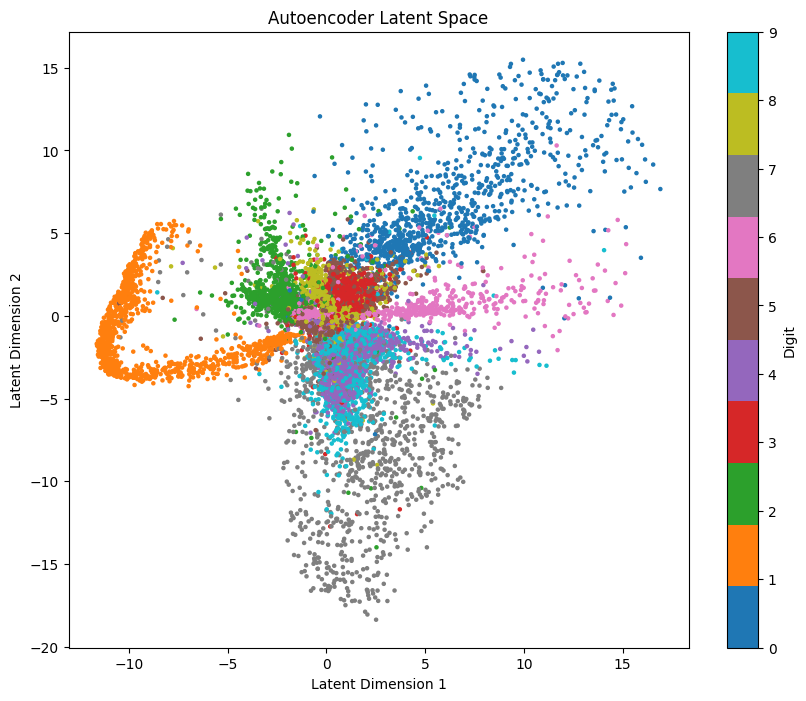

In [ ]:
# Plot AE latent space

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    z_ae[:, 0],
    z_ae[:, 1],
    c=y_test,
    cmap="tab10",
    s=5
)

plt.colorbar(scatter, label="Digit")
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.title("Autoencoder Latent Space")

plt.show()

In [ ]:
# VAE Encoder

class VAEEncoder(tf.keras.Model):

    def __init__(self, latent_dim):
        super().__init__()

        self.flatten = tf.keras.layers.Flatten()

        self.dense1 = tf.keras.layers.Dense(
            128,
            activation="relu"
        )

        self.dense2 = tf.keras.layers.Dense(
            64,
            activation="relu"
        )

        self.z_mean = tf.keras.layers.Dense(
            latent_dim
        )

        self.z_log_var = tf.keras.layers.Dense(
            latent_dim
        )

    def call(self, inputs):

        x = self.flatten(inputs)

        x = self.dense1(x)

        x = self.dense2(x)

        mean = self.z_mean(x)

        log_var = self.z_log_var(x)

        return mean, log_var

In [ ]:
# Reparameterization trick

def sample_latent(mean, log_var):

    epsilon = tf.random.normal(
        shape=tf.shape(mean)
    )

    return mean + tf.exp(
        0.5 * log_var
    ) * epsilon

In [ ]:
# VAE Decoder

class VAEDecoder(tf.keras.Model):

    def __init__(self):

        super().__init__()

        self.dense1 = tf.keras.layers.Dense(
            64,
            activation="relu"
        )

        self.dense2 = tf.keras.layers.Dense(
            128,
            activation="relu"
        )

        self.output_layer = tf.keras.layers.Dense(
            784,
            activation="sigmoid"
        )

        self.reshape = tf.keras.layers.Reshape(
            (28, 28)
        )

    def call(self, z):

        x = self.dense1(z)

        x = self.dense2(x)

        x = self.output_layer(x)

        return self.reshape(x)

In [ ]:
# Create VAE

latent_dim = 2

vae_encoder = VAEEncoder(latent_dim)
vae_decoder = VAEDecoder()

print("VAE created successfully!")

VAE created successfully!


In [ ]:
# VAE loss function

def calculate_vae_loss(
    original,
    reconstructed,
    mean,
    log_var
):

    # Reconstruction loss
    reconstruction_loss = tf.reduce_mean(
        tf.reduce_sum(
            tf.square(
                original - reconstructed
            ),
            axis=[1, 2]
        )
    )

    # KL divergence
    kl_loss = -0.5 * tf.reduce_mean(
        tf.reduce_sum(
            1 + log_var
            - tf.square(mean)
            - tf.exp(log_var),
            axis=1
        )
    )

    # Total loss
    total_loss = reconstruction_loss + kl_loss

    return (
        total_loss,
        reconstruction_loss,
        kl_loss
    )

In [ ]:
# VAE training step

vae_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)


@tf.function
def train_vae_step(images):

    with tf.GradientTape() as tape:

        mean, log_var = vae_encoder(images)

        z = sample_latent(
            mean,
            log_var
        )

        reconstructed = vae_decoder(z)

        total_loss, reconstruction_loss, kl_loss = \
            calculate_vae_loss(
                images,
                reconstructed,
                mean,
                log_var
            )

    trainable_variables = (
        vae_encoder.trainable_variables
        + vae_decoder.trainable_variables
    )

    gradients = tape.gradient(
        total_loss,
        trainable_variables
    )

    vae_optimizer.apply_gradients(
        zip(
            gradients,
            trainable_variables
        )
    )

    return (
        total_loss,
        reconstruction_loss,
        kl_loss
    )

In [ ]:
# Create training dataset

vae_dataset = tf.data.Dataset.from_tensor_slices(
    x_train
)

vae_dataset = vae_dataset.shuffle(
    60000
).batch(128)

In [ ]:
# Train VAE

vae_total_losses = []
vae_reconstruction_losses = []
vae_kl_losses = []

for epoch in range(1, 21):

    epoch_total = []
    epoch_reconstruction = []
    epoch_kl = []

    for batch in vae_dataset:

        total_loss, reconstruction_loss, kl_loss = \
            train_vae_step(batch)

        epoch_total.append(
            total_loss.numpy()
        )

        epoch_reconstruction.append(
            reconstruction_loss.numpy()
        )

        epoch_kl.append(
            kl_loss.numpy()
        )

    avg_total = np.mean(epoch_total)
    avg_reconstruction = np.mean(
        epoch_reconstruction
    )
    avg_kl = np.mean(epoch_kl)

    vae_total_losses.append(avg_total)
    vae_reconstruction_losses.append(
        avg_reconstruction
    )
    vae_kl_losses.append(avg_kl)

    print(
        f"Epoch {epoch}/20 | "
        f"Total: {avg_total:.4f} | "
        f"Reconstruction: {avg_reconstruction:.4f} | "
        f"KL: {avg_kl:.4f}"
    )

Epoch 1/20 | Total: 54.3481 | Reconstruction: 51.4666 | KL: 2.8814
Epoch 2/20 | Total: 44.2358 | Reconstruction: 41.3384 | KL: 2.8974
Epoch 3/20 | Total: 42.8260 | Reconstruction: 39.6039 | KL: 3.2221
Epoch 4/20 | Total: 41.8451 | Reconstruction: 38.4016 | KL: 3.4436
Epoch 5/20 | Total: 41.1085 | Reconstruction: 37.4781 | KL: 3.6304
Epoch 6/20 | Total: 40.5352 | Reconstruction: 36.7742 | KL: 3.7610
Epoch 7/20 | Total: 40.0271 | Reconstruction: 36.1456 | KL: 3.8816
Epoch 8/20 | Total: 39.5588 | Reconstruction: 35.5462 | KL: 4.0126
Epoch 9/20 | Total: 39.1033 | Reconstruction: 34.9908 | KL: 4.1125
Epoch 10/20 | Total: 38.7118 | Reconstruction: 34.5009 | KL: 4.2109
Epoch 11/20 | Total: 38.4019 | Reconstruction: 34.1029 | KL: 4.2990
Epoch 12/20 | Total: 38.1181 | Reconstruction: 33.7518 | KL: 4.3662
Epoch 13/20 | Total: 37.8843 | Reconstruction: 33.4753 | KL: 4.4090
Epoch 14/20 | Total: 37.6888 | Reconstruction: 33.2300 | KL: 4.4588
Epoch 15/20 | Total: 37.5036 | Reconstruction: 32.9797 | 

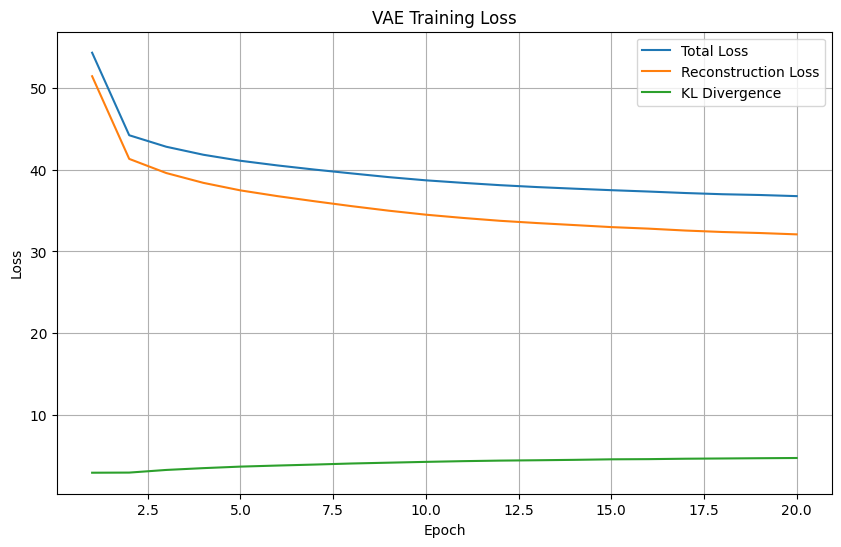

In [ ]:
# Plot VAE losses

epochs = range(1, 21)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    vae_total_losses,
    label="Total Loss"
)

plt.plot(
    epochs,
    vae_reconstruction_losses,
    label="Reconstruction Loss"
)

plt.plot(
    epochs,
    vae_kl_losses,
    label="KL Divergence"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training Loss")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Reconstruct test images

mean, log_var = vae_encoder(
    x_test[:10]
)

z = sample_latent(
    mean,
    log_var
)

reconstructed_images = vae_decoder(z)

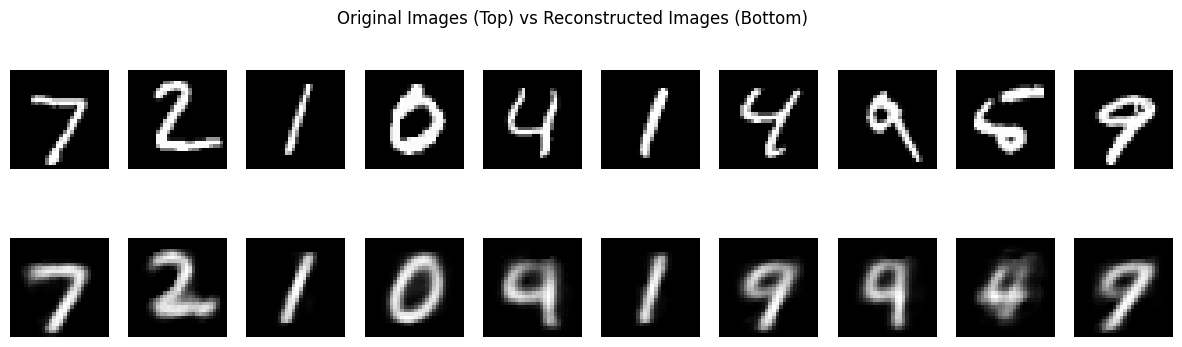

In [ ]:
# Original vs reconstructed

plt.figure(figsize=(15, 4))

for i in range(10):

    # Original
    plt.subplot(2, 10, i + 1)

    plt.imshow(
        x_test[i],
        cmap="gray"
    )

    plt.axis("off")

    # Reconstructed
    plt.subplot(2, 10, i + 11)

    plt.imshow(
        reconstructed_images[i],
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle(
    "Original Images (Top) vs Reconstructed Images (Bottom)"
)

plt.show()

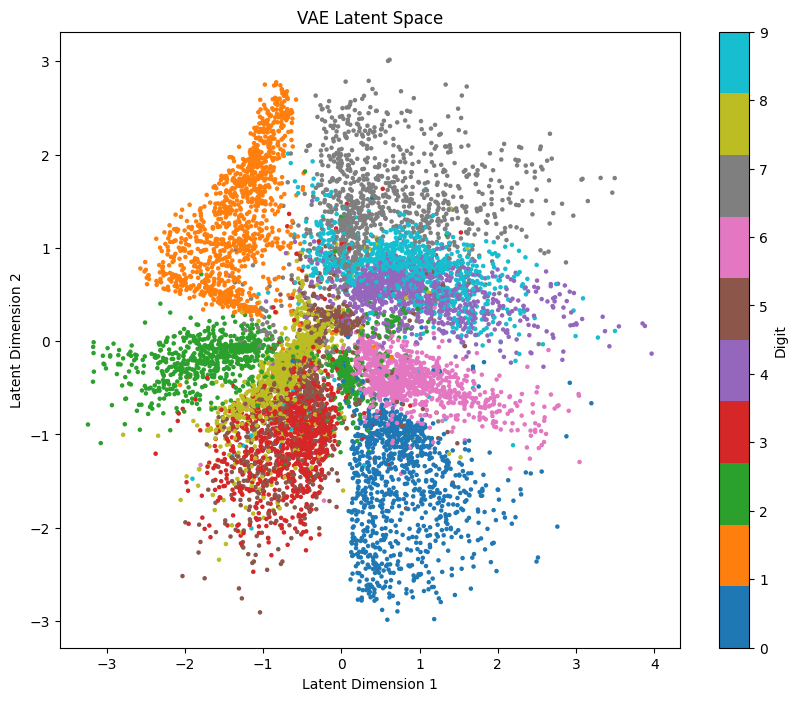

In [ ]:
# Generate VAE latent space

z_mean_test, z_log_var_test = vae_encoder(
    x_test
)

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    z_mean_test[:, 0],
    z_mean_test[:, 1],
    c=y_test,
    cmap="tab10",
    s=5
)

plt.colorbar(
    scatter,
    label="Digit"
)

plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")

plt.title("VAE Latent Space")

plt.show()

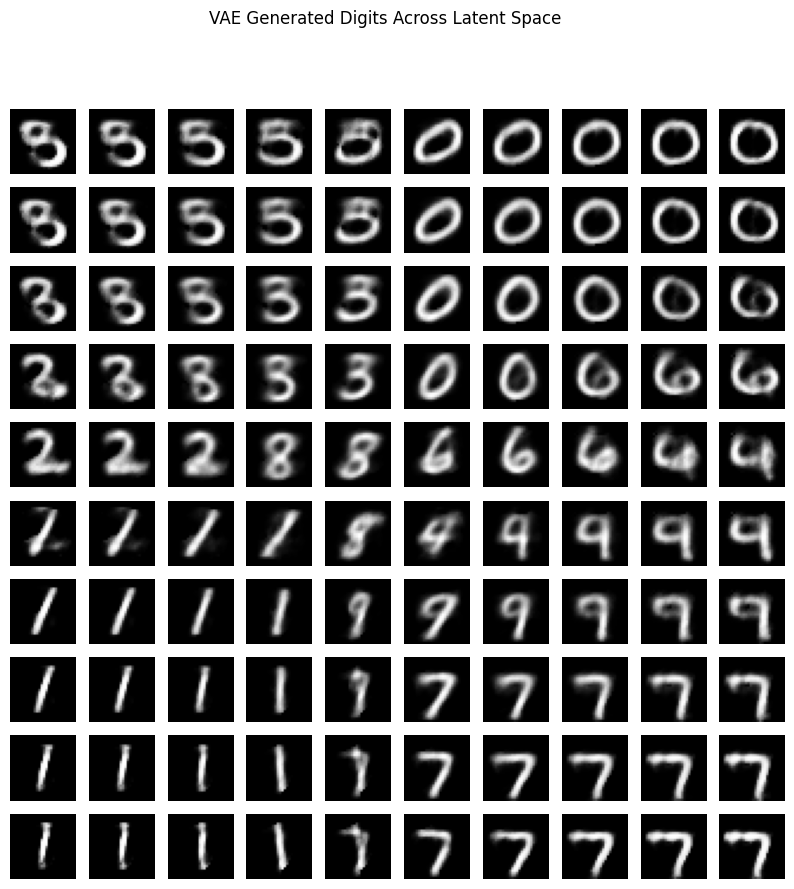

In [ ]:
# Generate digits across latent space

grid_size = 10

grid = np.linspace(
    -3,
    3,
    grid_size
)

plt.figure(figsize=(10, 10))

for i, y in enumerate(grid):

    for j, x in enumerate(grid):

        z = tf.constant(
            [[x, y]],
            dtype=tf.float32
        )

        generated = vae_decoder(z)

        plt.subplot(
            grid_size,
            grid_size,
            i * grid_size + j + 1
        )

        plt.imshow(
            generated[0],
            cmap="gray"
        )

        plt.axis("off")

plt.suptitle(
    "VAE Generated Digits Across Latent Space"
)

plt.show()

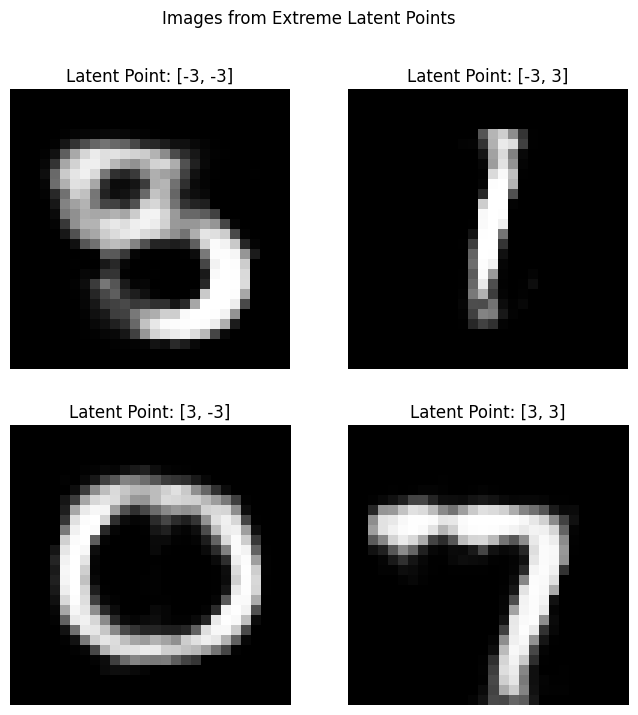

In [ ]:
# Extreme latent points

extreme_points = [
    [-3, -3],
    [-3, 3],
    [3, -3],
    [3, 3]
]

plt.figure(figsize=(8, 8))

for i, point in enumerate(extreme_points):

    z = tf.constant(
        [point],
        dtype=tf.float32
    )

    generated = vae_decoder(z)

    plt.subplot(2, 2, i + 1)

    plt.imshow(
        generated[0],
        cmap="gray"
    )

    plt.title(
        f"Latent Point: {point}"
    )

    plt.axis("off")

plt.suptitle(
    "Images from Extreme Latent Points"
)

plt.show()

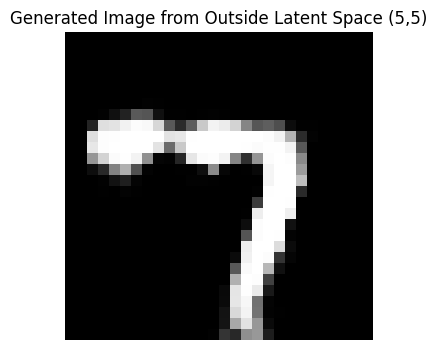

In [ ]:
# Point outside the learned latent space

outside_point = tf.constant(
    [[5.0, 5.0]],
    dtype=tf.float32
)

generated_outside = vae_decoder(
    outside_point
)

plt.figure(figsize=(4, 4))

plt.imshow(
    generated_outside[0],
    cmap="gray"
)

plt.title(
    "Generated Image from Outside Latent Space (5,5)"
)

plt.axis("off")

plt.show()